# Donation Allocations Analysis

Starter notebook for exploring `datasets/donation_allocations.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
csv_path = '../datasets/donation_allocations.csv'
df = pd.read_csv(csv_path)
df['allocation_date'] = pd.to_datetime(df['allocation_date'], errors='coerce')
df['amount_allocated'] = pd.to_numeric(df['amount_allocated'], errors='coerce')

print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
df.head()

Rows: 521
Columns: 7


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes
0,1,1,2,Education,717.18,2025-12-31,NaN
1,2,2,4,Transport,35.15,2025-12-02,NaN
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN
3,4,4,9,Operations,799.86,2023-09-11,NaN
4,5,5,8,Operations,1177.41,2023-11-08,NaN


In [3]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   allocation_id     521 non-null    int64         
 1   donation_id       521 non-null    int64         
 2   safehouse_id      521 non-null    int64         
 3   program_area      521 non-null    object        
 4   amount_allocated  521 non-null    float64       
 5   allocation_date   521 non-null    datetime64[ns]
 6   allocation_notes  0 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 28.6+ KB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
allocation_id,521.0,NaN,NaN,NaN,261.0,1.0,131.0,261.0,391.0,521.0,150.544013
donation_id,521.0,NaN,NaN,NaN,212.558541,1.0,113.0,213.0,315.0,420.0,119.628306
safehouse_id,521.0,NaN,NaN,NaN,4.794626,1.0,3.0,4.0,7.0,9.0,2.588074
program_area,521,6,Operations,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_allocated,521.0,NaN,NaN,NaN,542.104395,0.81,162.5,412.91,735.7,6481.54,601.289527
allocation_date,521,NaN,NaN,NaN,2024-08-05 08:03:41.113243648,2023-01-09 00:00:00,2023-10-19 00:00:00,2024-09-15 00:00:00,2025-06-15 00:00:00,2026-03-01 00:00:00,NaN
allocation_notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

allocation_notes    521
dtype: int64

In [5]:
total_allocated = df['amount_allocated'].sum()
allocations_count = df['allocation_id'].nunique()
donations_count = df['donation_id'].nunique()

print(f'Total allocated: ${total_allocated:,.2f}')
print(f'Unique allocations: {allocations_count:,}')
print(f'Unique donations represented: {donations_count:,}')

Total allocated: $282,436.39
Unique allocations: 521
Unique donations represented: 420


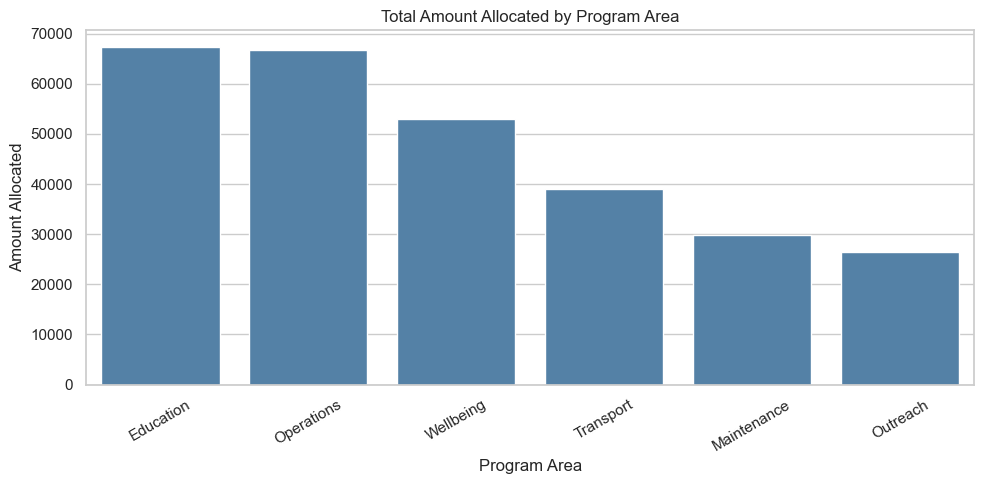

,program_area,amount_allocated
0,Education,67306.45
2,Operations,66853.09
5,Wellbeing,52948.52
4,Transport,39052.78
1,Maintenance,29894.24
3,Outreach,26381.31


In [6]:
program_summary = (
    df.groupby('program_area', as_index=False)['amount_allocated']
      .sum()
      .sort_values('amount_allocated', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=program_summary, x='program_area', y='amount_allocated', color='steelblue')
plt.title('Total Amount Allocated by Program Area')
plt.xlabel('Program Area')
plt.ylabel('Amount Allocated')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

program_summary

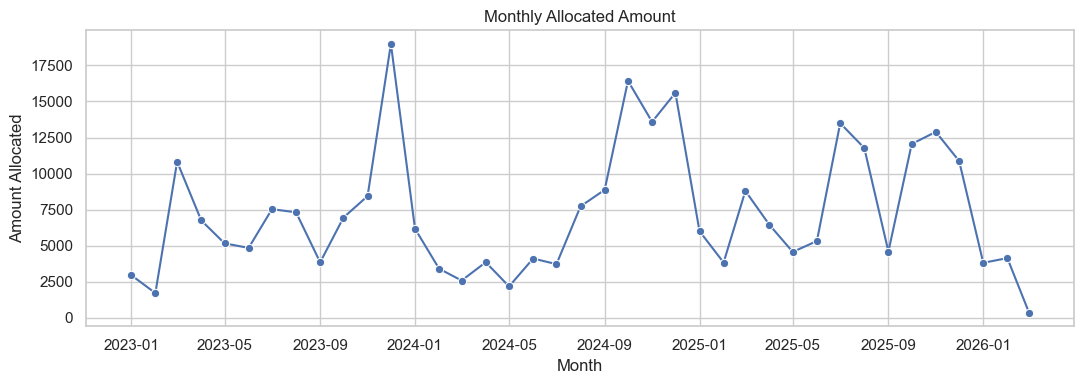

,month,amount_allocated
27,2025-04-01,6437.98
28,2025-05-01,4563.52
29,2025-06-01,5320.30
30,2025-07-01,13492.35
31,2025-08-01,11770.08
32,2025-09-01,4588.70
33,2025-10-01,12053.81
34,2025-11-01,12889.01
35,2025-12-01,10869.60
36,2026-01-01,3809.80


In [7]:
monthly = (
    df.dropna(subset=['allocation_date'])
      .assign(month=lambda x: x['allocation_date'].dt.to_period('M').dt.to_timestamp())
      .groupby('month', as_index=False)['amount_allocated']
      .sum()
      .sort_values('month')
)

plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='month', y='amount_allocated', marker='o')
plt.title('Monthly Allocated Amount')
plt.xlabel('Month')
plt.ylabel('Amount Allocated')
plt.tight_layout()
plt.show()

monthly.tail(12)

In [8]:
# 4) Modeling: explanatory + predictive
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

features = ['donation_id', 'safehouse_id', 'program_area']
X = df[features].copy()
y = df['amount_allocated'].copy()

num_cols = ['donation_id', 'safehouse_id']
cat_cols = ['program_area']

prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

explanatory_model = Pipeline([('prep', prep), ('model', LinearRegression())])
predictive_model = Pipeline([('prep', prep), ('model', RandomForestRegressor(n_estimators=200, random_state=42))])

explanatory_model.fit(X_train, y_train)
predictive_model.fit(X_train, y_train)
print('Both models trained.')

Both models trained.


In [9]:
# 5) Evaluation and Selection
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def eval_reg(model, X_eval, y_true):
    pred = model.predict(X_eval)
    return {
        'MAE': mean_absolute_error(y_true, pred),
        'RMSE': mean_squared_error(y_true, pred) ** 0.5,
        'R2': r2_score(y_true, pred)
    }

exp_scores = eval_reg(explanatory_model, X_test, y_test)
pred_scores = eval_reg(predictive_model, X_test, y_test)

results = pd.DataFrame([
    {'model': 'Explanatory (LinearRegression)', **exp_scores},
    {'model': 'Predictive (RandomForest)', **pred_scores}
]).sort_values('MAE')

results

,model,MAE,RMSE,R2
1,Predictive (RandomForest),382.022201,551.577178,-0.196786
0,Explanatory (LinearRegression),390.921295,503.717187,0.001893


In [10]:
# 6) Feature Selection (impact)
rf = predictive_model.named_steps['model']
feature_names = predictive_model.named_steps['prep'].get_feature_names_out()

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_features = importance.head(10)
print('Most impactful features:')
top_features

Most impactful features:


,feature,importance
0,num__donation_id,0.704202
1,num__safehouse_id,0.134277
3,cat__program_area_Maintenance,0.042589
2,cat__program_area_Education,0.034640
4,cat__program_area_Operations,0.026146
6,cat__program_area_Transport,0.025230
7,cat__program_area_Wellbeing,0.020657
5,cat__program_area_Outreach,0.012258


In [11]:
# 7) Deployment (simple artifact export)
import joblib
from pathlib import Path

best_model_name = results.iloc[0]['model']
best_model = predictive_model if 'RandomForest' in best_model_name else explanatory_model

out_dir = Path('../ml-pipelines/artifacts')
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, out_dir / 'donation_allocations_model.joblib')
top_features.to_csv(out_dir / 'donation_allocations_top_features.csv', index=False)

print('Saved: donation_allocations_model.joblib')
print('Saved: donation_allocations_top_features.csv')
print('Recommendation: use top features to guide funding decisions by program/safehouse.')

Saved: donation_allocations_model.joblib
Saved: donation_allocations_top_features.csv
Recommendation: use top features to guide funding decisions by program/safehouse.


## Phase Mapping (Added)

### 1) Problem Framing
- Business question: what drives `amount_allocated` and how accurately can we predict it?
- Explanatory goal: interpret relationships.
- Predictive goal: forecast allocation amount for new records.
- Success metrics: MAE, RMSE, R2.

### 2) Data Acquisition and Preparation
- Completed in earlier cells using `donation_allocations.csv`.
- Type conversion done for `allocation_date` and `amount_allocated`.

### 3) Exploration
- Completed in earlier cells with descriptive stats and trend charts.